In [1]:
import pandas as pd

## Loading Dataset

In [2]:
df = pd.read_csv('Crimes_2001_to_Present_2024.csv')

In [3]:
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,5741943,HN549294,08/25/2007 09:22:18 AM,074XX N ROGERS AVE,0560,ASSAULT,SIMPLE,OTHER,False,False,...,49.0,1.0,08A,NaN,NaN,2007,08/17/2015 03:03:40 PM,NaN,NaN,NaN
1,25953,JE240540,05/24/2021 03:06:00 PM,020XX N LARAMIE AVE,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,36.0,19.0,01A,1141387.0,1913179.0,2021,11/18/2023 03:39:49 PM,41.917838,-87.755969,"(41.917838056, -87.755968972)"
2,26038,JE279849,06/26/2021 09:24:00 AM,062XX N MC CORMICK RD,0110,HOMICIDE,FIRST DEGREE MURDER,PARKING LOT,True,False,...,50.0,13.0,01A,1152781.0,1941458.0,2021,11/18/2023 03:39:49 PM,41.995219,-87.713355,"(41.995219444, -87.713354912)"
3,13279676,JG507211,11/09/2023 07:30:00 AM,019XX W BYRON ST,0620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,...,47.0,5.0,05,1162518.0,1925906.0,2023,11/18/2023 03:39:49 PM,41.952345,-87.677975,"(41.952345086, -87.677975059)"
4,13274752,JG501049,11/12/2023 07:59:00 AM,086XX S COTTAGE GROVE AVE,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",SMALL RETAIL STORE,True,False,...,6.0,44.0,08B,1183071.0,1847869.0,2023,12/09/2023 03:41:24 PM,41.737751,-87.604856,"(41.737750767, -87.604855911)"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8155740 entries, 0 to 8155739
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Case Number           object 
 2   Date                  object 
 3   Block                 object 
 4   IUCR                  object 
 5   Primary Type          object 
 6   Description           object 
 7   Location Description  object 
 8   Arrest                bool   
 9   Domestic              bool   
 10  Beat                  int64  
 11  District              float64
 12  Ward                  float64
 13  Community Area        float64
 14  FBI Code              object 
 15  X Coordinate          float64
 16  Y Coordinate          float64
 17  Year                  int64  
 18  Updated On            object 
 19  Latitude              float64
 20  Longitude             float64
 21  Location              object 
dtypes: bool(2), float64(7), int64(3), object(1

In [5]:
df.drop(columns=['Beat','X Coordinate','Y Coordinate'], inplace=True)

In [6]:
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,District,Ward,Community Area,FBI Code,Year,Updated On,Latitude,Longitude,Location
0,5741943,HN549294,08/25/2007 09:22:18 AM,074XX N ROGERS AVE,0560,ASSAULT,SIMPLE,OTHER,False,False,24.0,49.0,1.0,08A,2007,08/17/2015 03:03:40 PM,NaN,NaN,NaN
1,25953,JE240540,05/24/2021 03:06:00 PM,020XX N LARAMIE AVE,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,25.0,36.0,19.0,01A,2021,11/18/2023 03:39:49 PM,41.917838,-87.755969,"(41.917838056, -87.755968972)"
2,26038,JE279849,06/26/2021 09:24:00 AM,062XX N MC CORMICK RD,0110,HOMICIDE,FIRST DEGREE MURDER,PARKING LOT,True,False,17.0,50.0,13.0,01A,2021,11/18/2023 03:39:49 PM,41.995219,-87.713355,"(41.995219444, -87.713354912)"
3,13279676,JG507211,11/09/2023 07:30:00 AM,019XX W BYRON ST,0620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,19.0,47.0,5.0,05,2023,11/18/2023 03:39:49 PM,41.952345,-87.677975,"(41.952345086, -87.677975059)"
4,13274752,JG501049,11/12/2023 07:59:00 AM,086XX S COTTAGE GROVE AVE,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",SMALL RETAIL STORE,True,False,6.0,6.0,44.0,08B,2023,12/09/2023 03:41:24 PM,41.737751,-87.604856,"(41.737750767, -87.604855911)"


### Missing values

In [7]:
df.isnull().sum()

ID                           0
Case Number                  0
Date                         0
Block                        0
IUCR                         0
Primary Type                 0
Description                  0
Location Description     13548
Arrest                       0
Domestic                     0
District                    47
Ward                    614829
Community Area          613453
FBI Code                     0
Year                         0
Updated On                   0
Latitude                 89845
Longitude                89845
Location                 89845
dtype: int64

In [8]:
#Handling Missing Values
df['Location Description'].fillna('Unknown', inplace=True)
df['Location'].fillna('Unknown', inplace=True)

latitude_mode = df['Latitude'].mode()[0] 
longitude_mode = df['Longitude'].mode()[0]  
df['Latitude'].fillna(latitude_mode, inplace=True)
df['Longitude'].fillna(longitude_mode, inplace=True)

missing_district = df['District'].isnull().sum()
df.dropna(subset=['District'], inplace=True)

ward_mode = df['Ward'].mode()[0]
community_area_mode = df['Community Area'].mode()[0]
df['Ward'].fillna(ward_mode, inplace=True)
df['Community Area'].fillna(community_area_mode, inplace=True)

## EDA

In [9]:
#Distribution of Crimes
df['Primary Type'].value_counts()

Primary Type
THEFT                                1725689
BATTERY                              1487156
CRIMINAL DAMAGE                       928789
NARCOTICS                             755736
ASSAULT                               540098
OTHER OFFENSE                         506613
BURGLARY                              435126
MOTOR VEHICLE THEFT                   411286
DECEPTIVE PRACTICE                    369751
ROBBERY                               307074
CRIMINAL TRESPASS                     220929
WEAPONS VIOLATION                     118428
PROSTITUTION                           70149
OFFENSE INVOLVING CHILDREN             58438
PUBLIC PEACE VIOLATION                 53650
SEX OFFENSE                            32699
CRIM SEXUAL ASSAULT                    27448
INTERFERENCE WITH PUBLIC OFFICER       19256
LIQUOR LAW VIOLATION                   15170
GAMBLING                               14644
ARSON                                  13967
HOMICIDE                               134

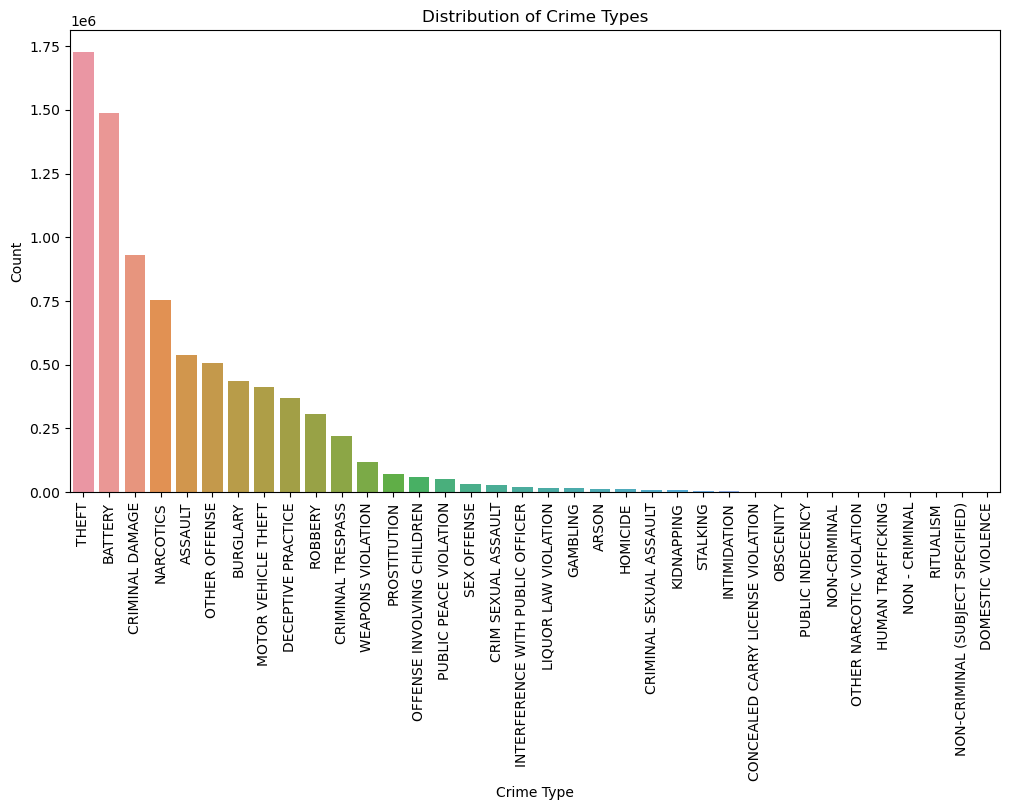

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Primary Type', order=df['Primary Type'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Distribution of Crime Types')
plt.xlabel('Crime Type')
plt.ylabel('Count')
plt.show()

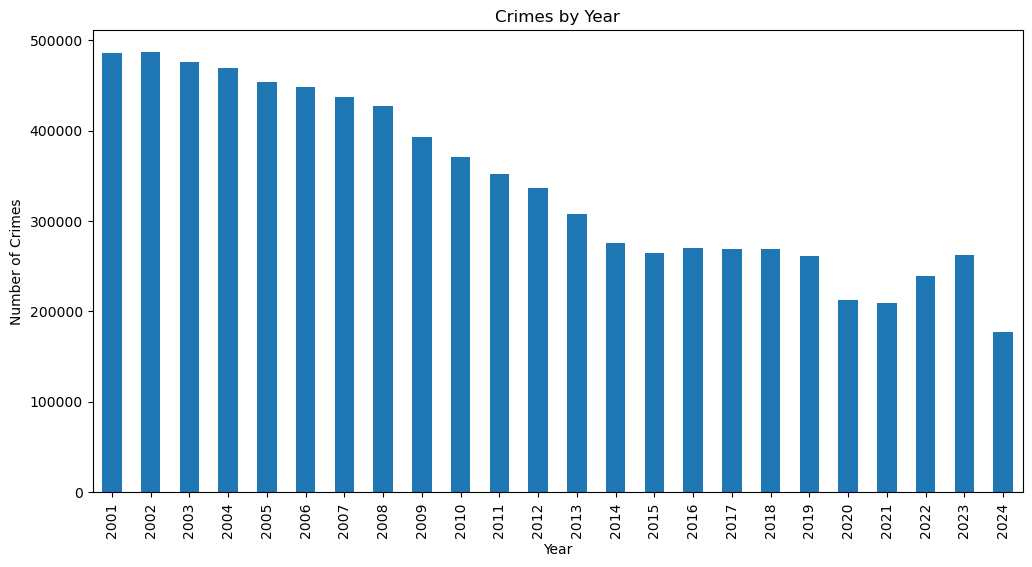

In [11]:
# Crime counts 
plt.figure(figsize=(12, 6))
df['Year'].value_counts().sort_index().plot(kind='bar')
plt.title('Crimes by Year')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.show()


Location Description
STREET                            2131732
RESIDENCE                         1350312
APARTMENT                          948538
SIDEWALK                           748613
OTHER                              269990
PARKING LOT/GARAGE(NON.RESID.)     202955
ALLEY                              181591
SMALL RETAIL STORE                 159126
SCHOOL, PUBLIC, BUILDING           146372
RESIDENCE-GARAGE                   135466
Name: count, dtype: int64


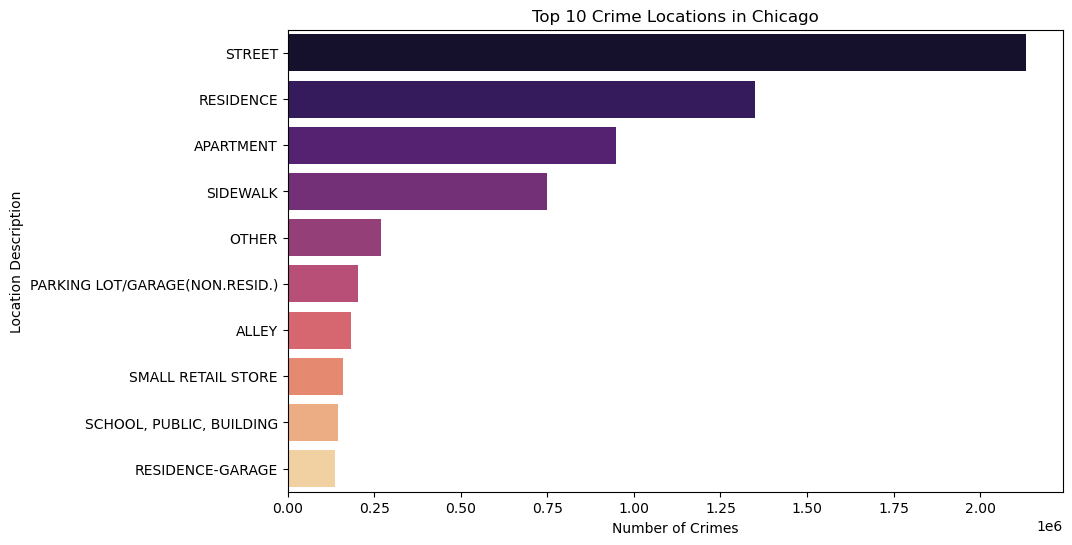

In [12]:
location_counts = df['Location Description'].value_counts().head(10)
print(location_counts)

# Visualization: Top 10 Locations
plt.figure(figsize=(10,6))
sns.barplot(x=location_counts.values, y=location_counts.index, palette='magma')
plt.xlabel('Number of Crimes')
plt.ylabel('Location Description')
plt.title('Top 10 Crime Locations in Chicago')
plt.show()


Primary Type
DOMESTIC VIOLENCE                    100.000000
PROSTITUTION                          99.579467
NARCOTICS                             99.357051
GAMBLING                              99.276154
LIQUOR LAW VIOLATION                  99.090310
PUBLIC INDECENCY                      98.522167
CONCEALED CARRY LICENSE VIOLATION     96.410256
INTERFERENCE WITH PUBLIC OFFICER      91.701288
OBSCENITY                             75.877690
WEAPONS VIOLATION                     72.439795
Name: Arrest, dtype: float64


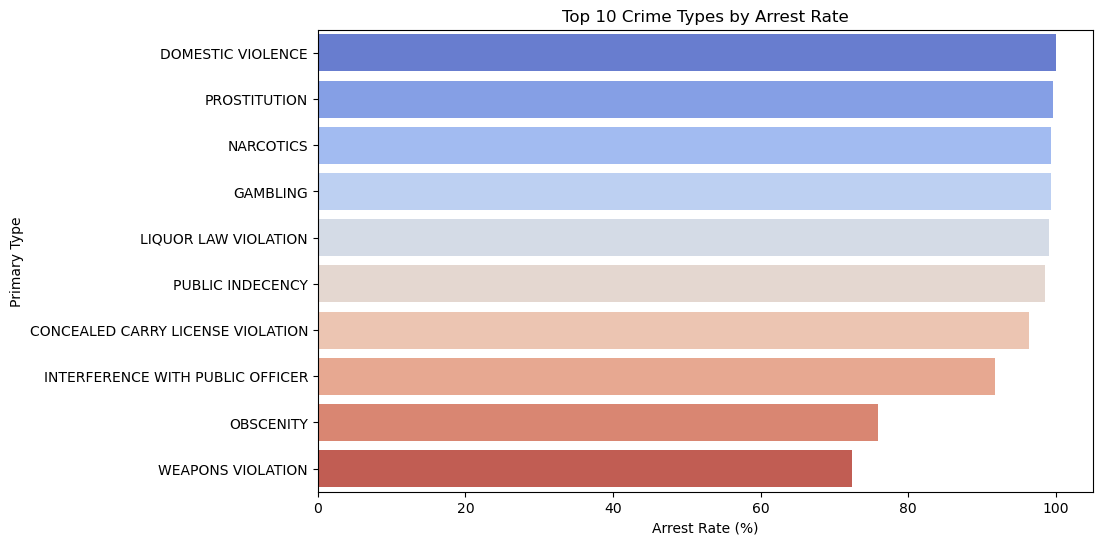

In [13]:
# Arrest rates
crime_arrest = df.groupby('Primary Type')['Arrest'].mean().sort_values(ascending=False).head(10) * 100
print(crime_arrest)

plt.figure(figsize=(10,6))
sns.barplot(x=crime_arrest.values, y=crime_arrest.index, palette='coolwarm')
plt.xlabel('Arrest Rate (%)')
plt.ylabel('Primary Type')
plt.title('Top 10 Crime Types by Arrest Rate')
plt.show()


In [14]:
if df['Date'].dtype != 'object':  
    df['Date'] = df['Date'].astype(str)  

df['Date'] = df['Date'].str.strip()

df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Updated On'] = pd.to_datetime(df['Updated On'],format='%m/%d/%Y %I:%M:%S %p', errors='coerce')  

categorical_cols = ['Block', 'IUCR', 'Primary Type', 'Description', 
                    'Location Description', 'FBI Code', 'Location']
for col in categorical_cols:
    df[col] = df[col].astype('category')

int_cols = ['ID', 'Year']
for col in int_cols:
    df[col] = pd.to_numeric(df[col], downcast='integer')

float_cols = ['Latitude', 'Longitude']
for col in float_cols:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [15]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['DayOfWeek'] = df['Date'].dt.dayofweek 
df['Hour'] = df['Date'].dt.hour
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,FBI Code,Year,Updated On,Latitude,Longitude,Location,Day,Month,DayOfWeek,Hour
0,5741943,HN549294,2007-08-25 09:22:18,074XX N ROGERS AVE,0560,ASSAULT,SIMPLE,OTHER,False,False,...,08A,2007,2015-08-17 15:03:40,41.976292,-87.905228,Unknown,25,8,5,9
1,25953,JE240540,2021-05-24 15:06:00,020XX N LARAMIE AVE,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,01A,2021,2023-11-18 15:39:49,41.917839,-87.755966,"(41.917838056, -87.755968972)",24,5,0,15
2,26038,JE279849,2021-06-26 09:24:00,062XX N MC CORMICK RD,0110,HOMICIDE,FIRST DEGREE MURDER,PARKING LOT,True,False,...,01A,2021,2023-11-18 15:39:49,41.995220,-87.713356,"(41.995219444, -87.713354912)",26,6,5,9
3,13279676,JG507211,2023-11-09 07:30:00,019XX W BYRON ST,0620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,...,05,2023,2023-11-18 15:39:49,41.952347,-87.677979,"(41.952345086, -87.677975059)",9,11,3,7
4,13274752,JG501049,2023-11-12 07:59:00,086XX S COTTAGE GROVE AVE,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",SMALL RETAIL STORE,True,False,...,08B,2023,2023-12-09 15:41:24,41.737751,-87.604858,"(41.737750767, -87.604855911)",12,11,6,7


#### Data Preparation 

#### Feature Engineering

#### Temporal Features
##### Is Weekend #####
##### Is Night (8pm to 6am) #####

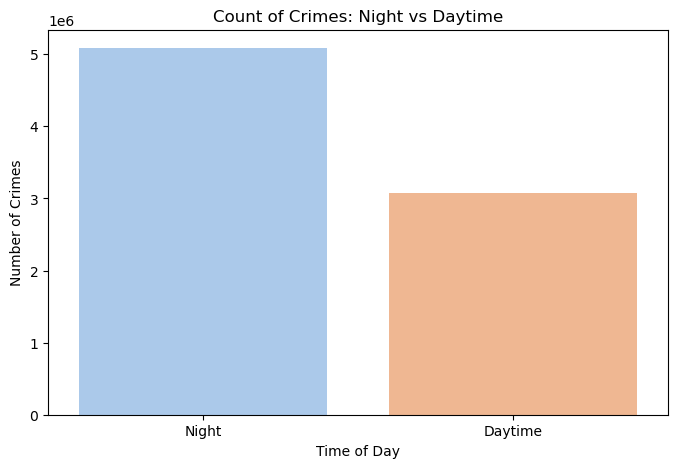

In [16]:
df['Is_Weekend'] = df['DayOfWeek'].isin(['Saturday', 'Sunday']).astype(int)

df['Is_Night'] = df['Hour'].apply(lambda x: 1 if x >= 20 or x < 6 else 0)

import matplotlib.pyplot as plt
import seaborn as sns
night_counts = df['Is_Night'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=night_counts.index, y=night_counts.values, palette='pastel')
plt.xticks(ticks=[0, 1], labels=['Night', 'Daytime'])
plt.title('Count of Crimes: Night vs Daytime')
plt.xlabel('Time of Day')
plt.ylabel('Number of Crimes')
plt.show()


#### Seasonal Trends

In [17]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season).astype('category')


C:\Users\anugu\AppData\Local\Temp\ipykernel_10584\296192646.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_counts = df.groupby('Season')['Count'].sum()


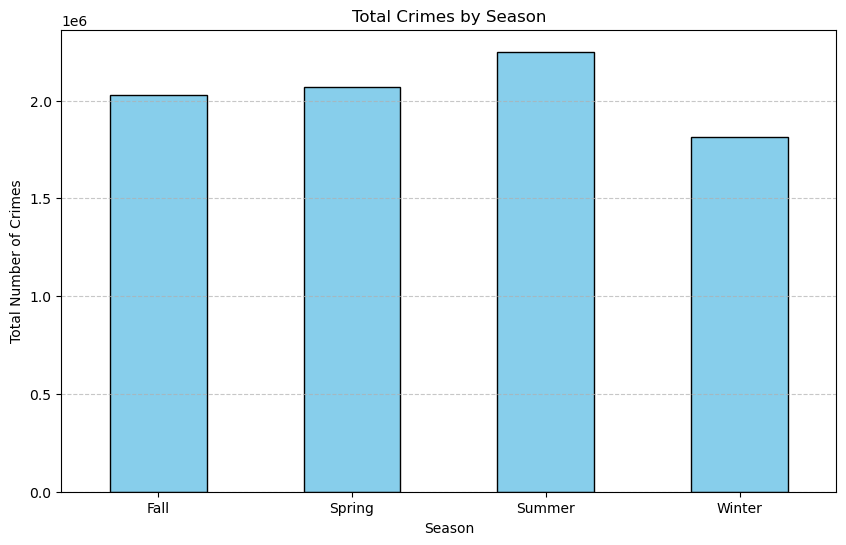

In [18]:
df['Count'] = 1  

season_counts = df.groupby('Season')['Count'].sum()

plt.figure(figsize=(10, 6))
season_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Crimes by Season')
plt.xlabel('Season')
plt.ylabel('Total Number of Crimes')
plt.xticks(rotation=0)  
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.show()


In [19]:
!pip install pmdarima


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

missing_dates = df['Date'].isnull().sum()
print(f'Missing Dates Count: {missing_dates}')

unique_dates_count = df['Date'].nunique()
print(f'Unique Dates Count: {unique_dates_count}')
print(f'Date Range: {df["Date"].min()} to {df["Date"].max()}')

df.set_index('Date', inplace=True)

time_series_data = df.resample('M').size() 

if time_series_data.empty:
    print("The resampled time series data is empty.")
else:
    print("Time Series Data Sample:", time_series_data.head())

Missing Dates Count: 0
Unique Dates Count: 3385780
Date Range: 2001-01-01 00:00:00 to 2024-09-09 00:00:00
Time Series Data Sample: Date
2001-01-31    38121
2001-02-28    33788
2001-03-31    40571
2001-04-30    40094
2001-05-31    41843
Freq: M, dtype: int64


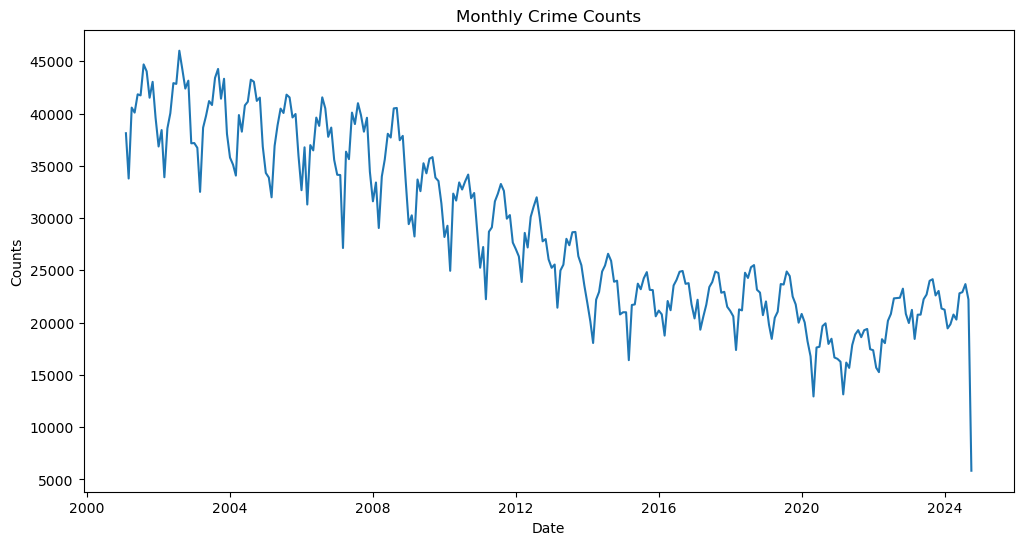

ADF Statistic: -0.34333818935724303
p-value: 0.9191381231698867
The time series is not stationary.


C:\Users\anugu\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Mean RMSE across 5 folds: 3104.7319643832425


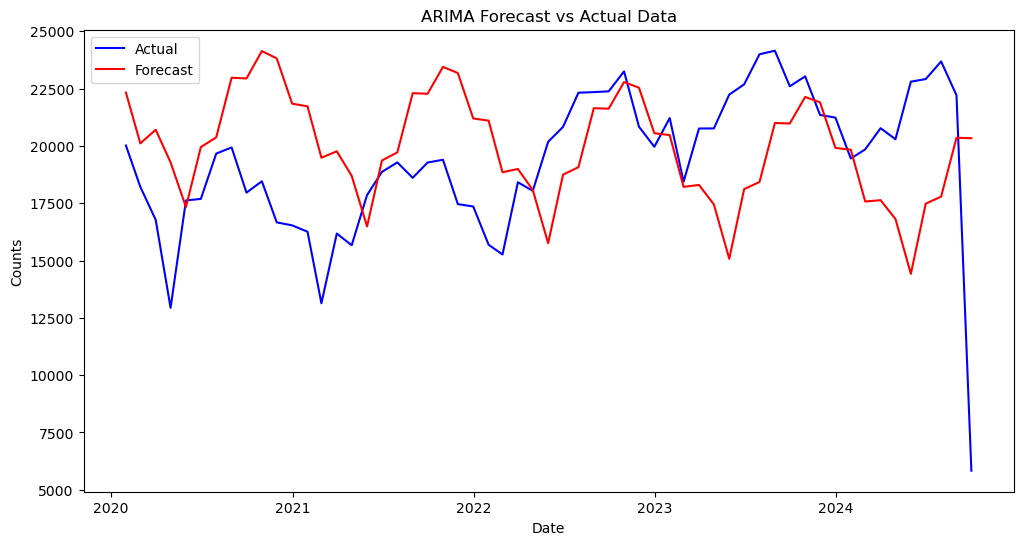

Root Mean Squared Error: 4168.525466766247


In [21]:
if time_series_data.empty:
    print("The resampled time series data is empty.")
else:
    #time series data
    plt.figure(figsize=(12, 6))
    plt.plot(time_series_data)
    plt.title('Monthly Crime Counts')
    plt.xlabel('Date')
    plt.ylabel('Counts')
    plt.show()

    #stationarity with the ADF test
    result = adfuller(time_series_data)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] < 0.05:
        print("The time series is stationary.")
    else:
        print("The time series is not stationary.")
    
    #Fit ARIMA model on training data
    train_size = int(len(time_series_data) * 0.8)
    train_data = time_series_data[:train_size]
    test_data = time_series_data[train_size:]

    # Cross-validation on training data
    n_splits = 5
    fold_size = len(train_data) // n_splits
    rmse_values = []

    for i in range(n_splits):
        train_fold = train_data[:(i + 1) * fold_size]
        val_fold = train_data[(i + 1) * fold_size:(i + 2) * fold_size]

        # Fit ARIMA model on the training fold
        model = ARIMA(train_fold, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
        arima_model = model.fit()

        # Forecast on validation fold
        forecast = arima_model.forecast(steps=len(val_fold))
        rmse = np.sqrt(mean_squared_error(val_fold, forecast))
        rmse_values.append(rmse)

    mean_rmse = np.mean(rmse_values)
    print(f'Mean RMSE across {n_splits} folds: {mean_rmse}')

    # Step 5: Forecast on test data
    forecast = arima_model.forecast(steps=len(test_data))  

    plt.figure(figsize=(12, 6))
    plt.plot(test_data.index, test_data, label='Actual', color='blue')
    plt.plot(test_data.index, forecast, label='Forecast', color='red')
    plt.title('ARIMA Forecast vs Actual Data')
    plt.xlabel('Date')
    plt.ylabel('Counts')
    plt.legend()
    plt.show()

    rmse = np.sqrt(mean_squared_error(test_data, forecast))
    print(f'Root Mean Squared Error: {rmse}')

In [22]:

print(f'Train Data Range: {train_data.index.min()} to {train_data.index.max()}')


Train Data Range: 2001-01-31 00:00:00 to 2019-12-31 00:00:00


In [23]:
comparison_df = pd.DataFrame({
    'Date': test_data.index,
    'Actual': test_data.values,
    'Forecast': forecast
})

print(comparison_df.head())
summary_stats = comparison_df[['Actual', 'Forecast']].describe()
print(summary_stats)


                 Date  Actual      Forecast
2019-10-31 2020-01-31   20018  22328.007448
2019-11-30 2020-02-29   18215  20110.254709
2019-12-31 2020-03-31   16777  20705.098851
2020-01-31 2020-04-30   12938  19281.784383
2020-02-29 2020-05-31   17622  17333.273163
             Actual      Forecast
count     57.000000     57.000000
mean   19327.122807  19954.761471
std     3212.395318   2247.810749
min     5832.000000  14419.783441
25%    17690.000000  18298.037875
50%    19666.000000  19949.803067
75%    21352.000000  21726.662779
max    24153.000000  24137.875843


#### Spatial Analysis

In [24]:
from scipy.spatial import cKDTree

def assess_safety(current_location, radius_km=0.2):
    current_lat, current_lon = current_location
    
    tree = cKDTree(df[['Latitude', 'Longitude']].values)
    
    indices = tree.query_ball_point([current_lat, current_lon], radius_km)
    nearby_crimes = df.iloc[indices]

    total_crimes = df.shape[0]
    crime_count = nearby_crimes.shape[0]
    
    crime_percentage = (crime_count / total_crimes) * 100 if total_crimes > 0 else 0
    
    top_crimes = nearby_crimes['Primary Type'].value_counts().head(5)
    
    return {
        "crime_count": crime_count,
        "crime_percentage": crime_percentage,
        "top_crimes": top_crimes.to_dict(),
        "nearby_crimes": nearby_crimes
    }

current_location = (41.7943, -87.5856) #Hyde Park (near the University of Chicago)
safety_report = assess_safety(current_location, radius_km=0.2)


print("Safety Assessment Report:")
print(f"Total Crimes in {0.2} km: {safety_report['crime_count']}")
print(f"Crime Percentage in the area: {safety_report['crime_percentage']:.2f}%")
print("Top Crimes Nearby:")
for crime_type, count in safety_report['top_crimes'].items():
    print(f"{crime_type}: {count}")

Safety Assessment Report:
Total Crimes in 0.2 km: 6839809
Crime Percentage in the area: 83.87%
Top Crimes Nearby:
THEFT: 1437807
BATTERY: 1270896
CRIMINAL DAMAGE: 760476
NARCOTICS: 662816
ASSAULT: 462808


In [25]:
from scipy.spatial import cKDTree

def assess_safety(current_location, radius_km=0.2):
    current_lat, current_lon = current_location
    
    tree = cKDTree(df[['Latitude', 'Longitude']].values)
    
    indices = tree.query_ball_point([current_lat, current_lon], radius_km)
    nearby_crimes = df.iloc[indices]

    total_crimes = df.shape[0]
    crime_count = nearby_crimes.shape[0]
    
    crime_percentage = (crime_count / total_crimes) * 100 if total_crimes > 0 else 0
    
    top_crimes = nearby_crimes['Primary Type'].value_counts().head(5)
    
    return {
        "crime_count": crime_count,
        "crime_percentage": crime_percentage,
        "top_crimes": top_crimes.to_dict(),
        "nearby_crimes": nearby_crimes
    }

current_location = (41.9116, -87.6334) #Old Town
safety_report = assess_safety(current_location, radius_km=0.2)


print("Safety Assessment Report:")
print(f"Total Crimes in {0.2} km: {safety_report['crime_count']}")
print(f"Crime Percentage in the area: {safety_report['crime_percentage']:.2f}%")
print("Top Crimes Nearby:")
for crime_type, count in safety_report['top_crimes'].items():
    print(f"{crime_type}: {count}")

Safety Assessment Report:
Total Crimes in 0.2 km: 7401646
Crime Percentage in the area: 90.75%
Top Crimes Nearby:
THEFT: 1592635
BATTERY: 1348716
CRIMINAL DAMAGE: 835162
NARCOTICS: 692721
ASSAULT: 484657
